In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Load dataset (use your path)
df = pd.read_excel("D:/Data Analysis project/Superstore.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [2]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (51290, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  obj

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna(0)

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [4]:
# Create Month (numeric)
df['Month'] = df['Order Date'].dt.month

# Create Year
df['Year'] = df['Order Date'].dt.year

# Profit Margin
df['Profit_Margin'] = df['Profit'] / df['Sales']

# Delivery time (VERY IMPRESSIVE 🔥)
df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [5]:
print("Null values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

# Outliers
outliers = df[df['Sales'] > df['Sales'].quantile(0.99)]
print("Outliers:\n", outliers)

Null values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Postal Code       0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
Month             0
Year              0
Profit_Margin     0
Delivery_Days     0
dtype: int64
Duplicate rows: 0
Outliers:
        Row ID         Order ID Order Date  Ship Date       Ship Mode  \
0       32298   CA-2012-124891 2012-07-31 2012-07-31        Same Day   
1       26341    IN-2013-77878 2013-02-05 2013-02-07    Second Class   
2       25330    IN-2013-71249 2013-10-17 2013-10-18     First Class   
3       13524  ES-2013-1579342 2013-01-28 2013-01-30     First Class   
4       47221     SG-201

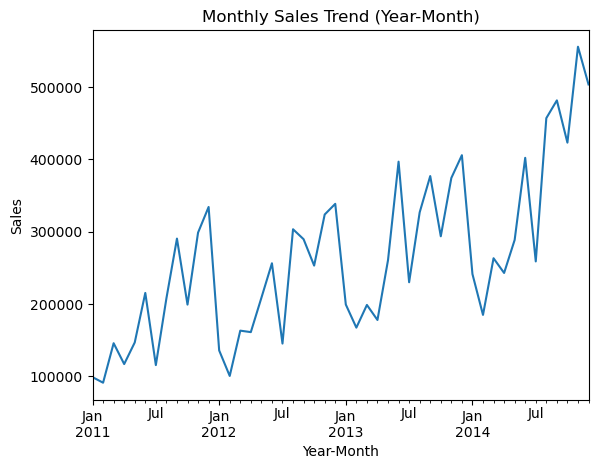

In [6]:
# Create YearMonth column
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Group data
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

# Plot
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend (Year-Month)")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.show()

In [7]:
top_products = df.groupby('Sub-Category')['Sales'].sum() \
                 .sort_values(ascending=False).head(5)

print("Top 5 Sub-Categories:\n", top_products)

Top 5 Sub-Categories:
 Sub-Category
Phones       1.706824e+06
Copiers      1.509436e+06
Chairs       1.501682e+06
Bookcases    1.466572e+06
Storage      1.127086e+06
Name: Sales, dtype: float64


In [8]:
region_sales = df.groupby('Region')['Sales'].sum()
print("Region Sales:\n", region_sales)

Region Sales:
 Region
Africa            7.837732e+05
Canada            6.692817e+04
Caribbean         3.242809e+05
Central           2.822303e+06
Central Asia      7.528266e+05
EMEA              8.061613e+05
East              6.787812e+05
North             1.248166e+06
North Asia        8.483098e+05
Oceania           1.100185e+06
South             1.600907e+06
Southeast Asia    8.844232e+05
West              7.254578e+05
Name: Sales, dtype: float64


In [9]:
delivery = df.groupby('Region')['Delivery_Days'].mean()
print("Avg Delivery Days:\n", delivery)

Avg Delivery Days:
 Region
Africa            3.910399
Canada            3.677083
Caribbean         3.973964
Central           4.033642
Central Asia      4.005371
EMEA              3.933386
East              3.909761
North             4.033856
North Asia        3.907613
Oceania           3.932894
South             3.944018
Southeast Asia    4.031640
West              3.930066
Name: Delivery_Days, dtype: float64


In [10]:
# Clean discount values (fix messy decimals)
df['Discount_Rounded'] = df['Discount'].round(2)

# Group by cleaned discount
profit_discount = df.groupby('Discount_Rounded')['Profit'].mean()

# Sort values (important for graph)
profit_discount = profit_discount.sort_index()

print("Profit vs Discount:\n", profit_discount)

Profit vs Discount:
 Discount_Rounded
0.00      62.051980
0.07     140.990022
0.10      63.683426
0.15      50.602409
0.17      38.317107
0.20      23.242825
0.25       4.043371
0.27      -4.317213
0.30     -57.899557
0.32     -88.560656
0.35    -116.144693
0.37     -78.462191
0.40     -47.296221
0.45     -41.610973
0.47     -42.982420
0.50     -97.140158
0.55    -315.067200
0.57    -526.129000
0.60     -83.223315
0.65    -365.997971
0.70    -104.339576
0.80    -122.203244
0.85   -1534.329000
Name: Profit, dtype: float64


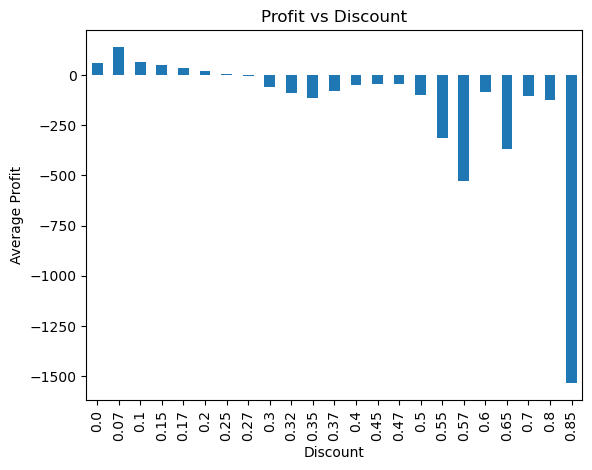

In [11]:
plt.figure()
profit_discount.plot(kind='bar')
plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

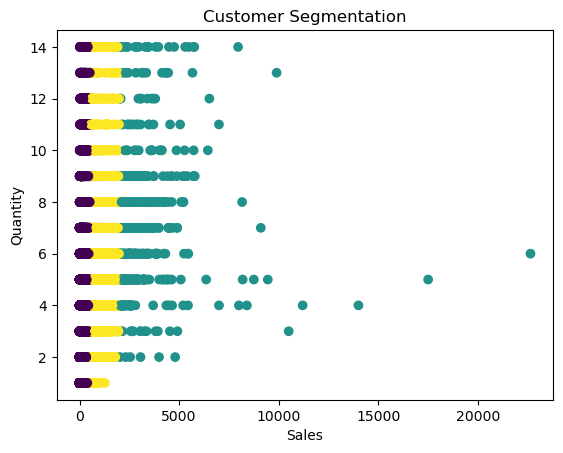

In [19]:
plt.figure()
plt.scatter(df['Sales'], df['Quantity'], c=df['Cluster'])
plt.xlabel("Sales")
plt.ylabel("Quantity")
plt.title("Customer Segmentation")
plt.show()

In [21]:
discount = df[df['Discount'] > 0]['Sales']
no_discount = df[df['Discount'] == 0]['Sales']

print("With Discount:", discount.mean())
print("Without Discount:", no_discount.mean())

With Discount: 253.58336519366281
Without Discount: 241.0428125754076


In [35]:
X = df[['Sales', 'Quantity']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df[['Sales', 'Quantity', 'Cluster']].head()

,Sales,Quantity,Cluster
0,2309.650,7,1
1,3709.395,9,1
2,5175.171,9,1
3,2892.510,5,1
4,2832.960,8,1


In [29]:
# Step 1: Create Year & Month (if not already done)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Step 2: Group data
df_grouped = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Step 3: Create time index
df_grouped['Time'] = range(len(df_grouped))

# Step 4: Prepare data
X = df_grouped[['Time']]
y = df_grouped['Sales']

# Step 5: Train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

# Step 6: Predict next time step
import pandas as pd
next_time = pd.DataFrame({'Time': [len(df_grouped)+1]})

prediction = model.predict(next_time)

print("Predicted Future Sales:", prediction[0])

Predicted Future Sales: 413351.03132440906


In [41]:
df.to_csv("D:/Data Analysis project/cleaned_superstore.csv", index=False)
print("Saved cleaned_superstore.csv")


Saved cleaned_superstore.csv
